#  Run of Model **$X$** on the App **MASSA**
 
**Paramaters**
The parameters of all models should be available in the parent folder, in an EXCEL file.

### Imports

In [1]:
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
import torch

from neuralhydrology.evaluation import metrics
from neuralhydrology.nh_run import start_run, eval_run
from neuralhydrology.datasetzoo import register_dataset

### Adding our Dataset | Metrics | Models

In [2]:
from custom.dataset.swisshourly import SwissHourly
register_dataset("swisshourly", SwissHourly)
from neuralhydrology.utils.config import Config

# Custom functions plot_training_curves
from custom.functions.Plot import plot_hydrograph, plot_training_curves, plot_validation_metrics
from custom.functions.utils_fla import parse_neuralhydrology_log


---

### Run parameters

In [3]:
configPath = Path("m2_base.yml")

runFile = "m2_base"

cfg = Config(configPath)
TRAIN = True
Evaluation_TEST =  False # False


---
## **Training**

In [4]:
import pandas as pd
csv_path = r"..\..\data\massa_2.csv"
data = pd.read_csv(csv_path)
# print("Columns of the csv:  ", data.columns)
# print(data.dtypes)
# data['date'] = pd.to_datetime(data['date'])


# print some information about the dataset

# print(data.head())
# print(data.describe())

In [ ]:
if TRAIN:
    print("--- Starting the training of the model ---")
    # by default we assume that you have at least one cuda-capable nvidia gpu or macos with metal support
    if torch.cuda.is_available() or torch.backends.mps.is_available():
        print("Using GPU")
        start_run(config_file=Path(configPath))
    # fall back to cpu-only mode
    else:
        print("Using CPU")
        start_run(config_file=Path(configPath), gpu=-1)
    print("==================================")
    print("  Training ended successfully !   ")
    print("==================================")
else: print(" Training step skipped !")

--- Starting the training of the model ---
Using GPU
2025-10-28 15:42:14,762: Logging to c:\Users\Kohler\Documents\NeuralHydrology_FK\neuralhydrology\test_Fla\Massa\LSTM_hind_forecast_v0\m2\runs\m2_base_2810_154214\output.log initialized.
2025-10-28 15:42:14,763: ### Folder structure created at c:\Users\Kohler\Documents\NeuralHydrology_FK\neuralhydrology\test_Fla\Massa\LSTM_hind_forecast_v0\m2\runs\m2_base_2810_154214
2025-10-28 15:42:14,764: ### Run configurations for m2_base
2025-10-28 15:42:14,765: experiment_name: m2_base
2025-10-28 15:42:14,765: base_run_dir: runs
2025-10-28 15:42:14,766: train_dir: c:\Users\Kohler\Documents\NeuralHydrology_FK\neuralhydrology\test_Fla\Massa\LSTM_hind_forecast_v0\m2\runs\m2_base_2810_154214\train_data
2025-10-28 15:42:14,766: img_log_dir: c:\Users\Kohler\Documents\NeuralHydrology_FK\neuralhydrology\test_Fla\Massa\LSTM_hind_forecast_v0\m2\runs\m2_base_2810_154214\img_log
2025-10-28 15:42:14,767: seed: 42
2025-10-28 15:42:14,767: device: cuda:0
2025-

### Plot of the Loss and Metrics

✅ Parsed 40 training epochs and 40 validation evaluations.
Plotting the losses and metrics throughout the training process: 


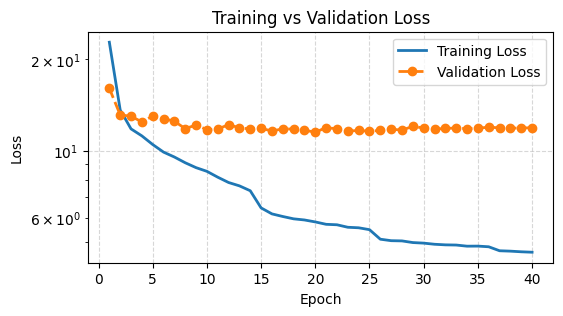

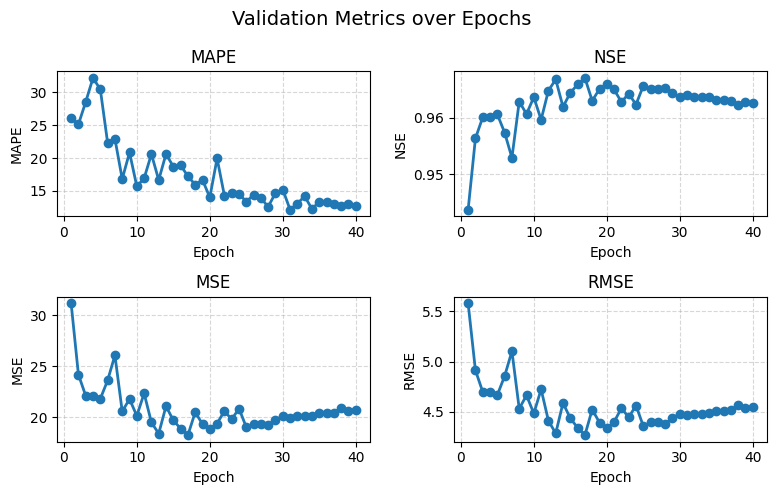

In [ ]:
# Path to your output.log file
log_path = Path(f"{cfg.base_run_dir}/{runFile}/output.log")
train_df, val_df = parse_neuralhydrology_log(log_path)

print("Plotting the losses and metrics throughout the training process: ")
plot_training_curves(train_df, val_df)
plot_validation_metrics(val_df)


---

## Evaluation on the **TEST** Dataset
The run directory that needs to be specified for evaluation is printed in the output log above. Since the folder name is created dynamically (including the date and time of the start of the run) you will need to change the `run_dir` argument according to your local directory name. By default, it will use the same device as during the training process.

In [ ]:
run_dir = Path(f"{cfg.base_run_dir}/{runFile}")

if Evaluation_TEST:
    print(" Starting the EVALUATION on the test period:  ")
    eval_run(run_dir=run_dir, period="test")
    print("==================================")
    print("  TEST ended successfully !   ")
    print("==================================")
else: print(" Testing process skipped !")

 Testing process skipped !


---

### Load and inspect model predictions
Next, we load the results file and compare the model predictions with observations. The results file is always a pickled dictionary with one key per basin (even for a single basin). The next-lower dictionary level is the temporal resolution of the predictions. 

In this case, we trained a model only on daily data ('1D'). Within the temporal resolution, the next-lower dictionary level are `xr`(an xarray Dataset that contains observations and predictions), as well as one key for each metric that was specified in the config file.

NOTE: The data variables in the xarray Dataset are named according to the name of the target variables, with suffix `_obs` for the observations and suffix `_sim` for the simulations.

In [ ]:
# model_str = f"model_epoch{str(cfg.epochs).zfill(3)}"
model_str = f"model_epoch055"
testPath = Path(run_dir / "test" / f"{model_str}" / "test_results.p")
with open(testPath, "rb") as fp:
    results = pickle.load(fp)
basin = "massa_2"
# results.keys()
results[basin]['1h']

FileNotFoundError: [Errno 2] No such file or directory: 'runs\\m2_base\\test\\model_epoch055\\test_results.p'

### Plotting model predictions vs observations

Code for 24h predictions:

In [ ]:
from custom.functions.Plot import plot_forecast_24h, plot_forecast_horizon_24h,plot_forecast_horizon_series
from custom.functions.utils_fla import info_results, mape_array, dict_without_xr_key
from custom.functions.Plot import plot_mape_horizon

results_ = results[basin]["1h"]["xr"]
scores = dict_without_xr_key(results[basin]['1h'])

# store only the values in numpy arrays from xarray DataArrays
y_true = results_['streamflow_obs']#.values
y_pred = results_['streamflow_sim']#.values
# print(y_pred-y_true)
verb = False
if verb: 
    print("\n-- Calculating MAPE values for each horizon: --\n")
    mapes = mape_array(y_true, y_pred, verbose=verb)
    print("\n-- MAPE calculation per horizon completed. --\n")
else:
    mapes = mape_array(y_true, y_pred, verbose=verb)


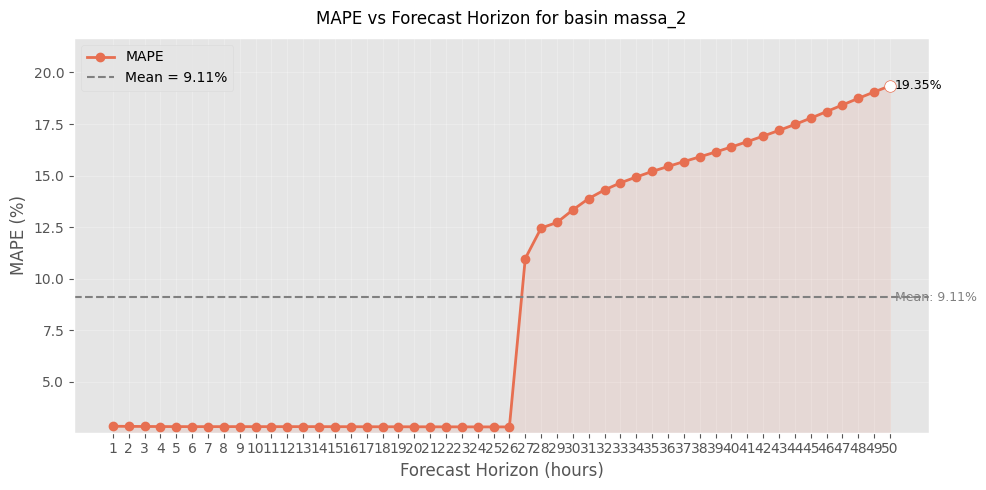

In [ ]:
# Example usage (variables `mapes`, `horizons`, and `basin` exist in the notebook):
plot_mape_horizon(
    mapes,
    color="#e76f51",
    title=f"MAPE vs Forecast Horizon for basin {basin}"
)


In [ ]:
from custom.functions.Plot import plot_forecast_24h, plot_forecast_horizon_24h,plot_forecast_horizon_series

scores_str = str.join(', ', [f"{key} : {scores[key]:.2f}" for key in scores])
title24 = f"Massa – {cfg.predict_last_n}h | " + scores_str
# plot_forecast_24h(measured=y_true, predicted=y_pred, title=title24, mode="list", horizons=[1, 6, cfg.predict_last_n])
plot_forecast_24h(measured=y_true, predicted=y_pred, title=title24, mode="list", horizons=[cfg.predict_last_n])


In [ ]:
# Example: visualize forecast issued on April 10, 2024, at midnight
plot_forecast_horizon_24h(
    issue_date="2024-08-10 00:00:00",
    xr_ds=results_
).show()
plot_forecast_horizon_24h(
    issue_date="2024-08-10 01:00:00",
    xr_ds=results_
).show()

In [ ]:
plot_forecast_horizon_series(
    issue_date="2024-06-10 00:00:00",
    xr_ds=results_,
    n_forecasts=10
).show()

---

## Computation of all metric scores
Next, we are going to compute all metrics that are implemented in the NeuralHydrology package. You will find additional hydrological signatures implemented in `neuralhydrology.evaluation.signatures`.

In [ ]:
qobs=results_['streamflow_obs']
qsim=results_['streamflow_sim']
values = metrics.calculate_all_metrics(qobs.isel(time_step=-1), qsim.isel(time_step=-1))

for key, val in values.items():
    print(f"{key}: {val:.3f}")

NSE: 0.859
MSE: 89.599
RMSE: 9.466
KGE: 0.909
Alpha-NSE: 1.037
Beta-KGE: 1.050
Beta-NSE: 0.042
Pearson-r: 0.933
FHV: -4.251
FMS: 4.568
FLV: -25.575
Peak-Timing: nan
Peak-MAPE: 17.775
MAPE: 19.354


In [ ]:
values = metrics.calculate_all_metrics(qobs.isel(time_step=6), qsim.isel(time_step=6))
for key, val in values.items():
    print(f"{key}: {val:.3f}")

NSE: 0.999
MSE: 0.333
RMSE: 0.577
KGE: 0.999
Alpha-NSE: 1.000
Beta-KGE: 1.000
Beta-NSE: 0.000
Pearson-r: 1.000
FHV: -0.669
FMS: 0.309
FLV: 24.263
Peak-Timing: nan
Peak-MAPE: 2.336
MAPE: 2.830
